In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
listing = pd.read_csv(r"D:\Data Analyst\DA Project-2\Airbnb_Automated_Pipeline_Project\data\processed\clean_listings.csv")
listing.head()

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",no response,1.0,0.98,False,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,False
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",no response,1.0,0.98,False,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,False
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",no response,1.0,0.98,False,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,False
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",no response,1.0,0.98,False,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,False
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",no response,1.0,0.98,False,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,False


In [3]:
listing.info()

<class 'pandas.DataFrame'>
RangeIndex: 247969 entries, 0 to 247968
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   247969 non-null  int64  
 1   name                         247818 non-null  str    
 2   host_id                      247969 non-null  int64  
 3   host_since                   247826 non-null  str    
 4   host_location                247969 non-null  str    
 5   host_response_time           247969 non-null  str    
 6   host_response_rate           247969 non-null  float64
 7   host_acceptance_rate         247969 non-null  float64
 8   host_is_superhost            247969 non-null  bool   
 9   host_total_listings_count    247969 non-null  float64
 10  host_has_profile_pic         247969 non-null  bool   
 11  host_identity_verified       247969 non-null  bool   
 12  neighbourhood                247969 non-null  str    
 13  city      

In [4]:
listing.shape

(247969, 32)

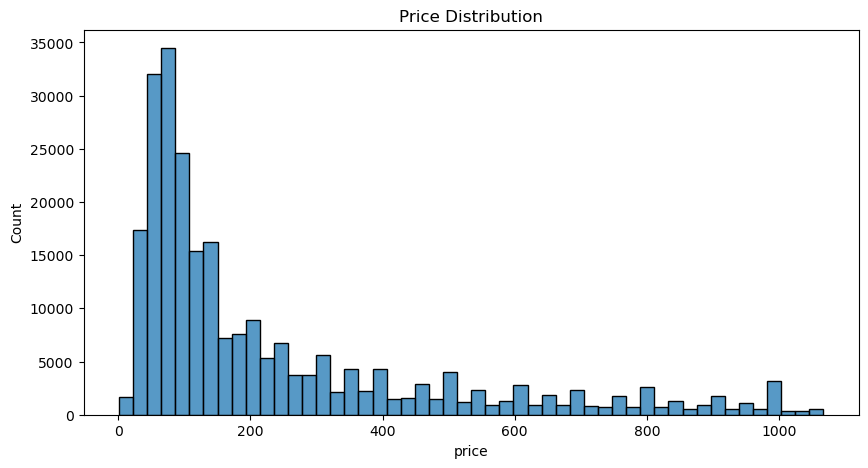

In [6]:
plt.figure(figsize=(10,5))
sns.histplot(listing["price"], bins=50)
plt.title("Price Distribution")
plt.show()

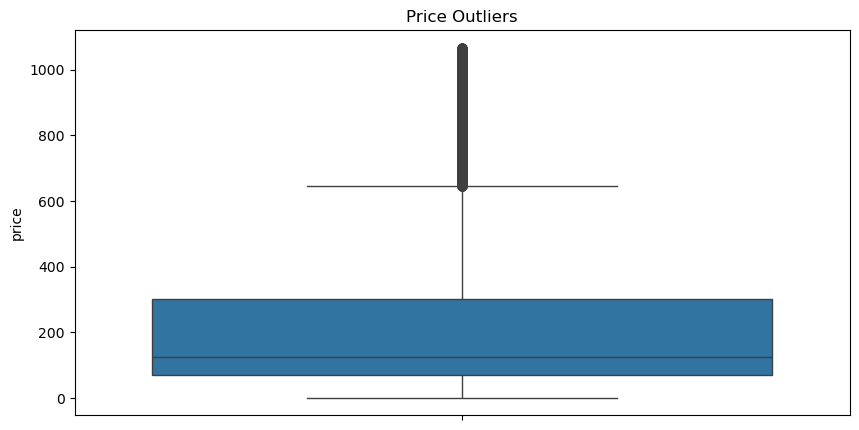

In [8]:
plt.figure(figsize=(10,5))
sns.boxplot(listing["price"])
plt.title("Price Outliers")
plt.show()

C:\Users\Intelb\AppData\Local\Temp\ipykernel_19008\1292731446.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="room_type", y="price", data=listing, palette=["red", "green", "blue", "purple"])


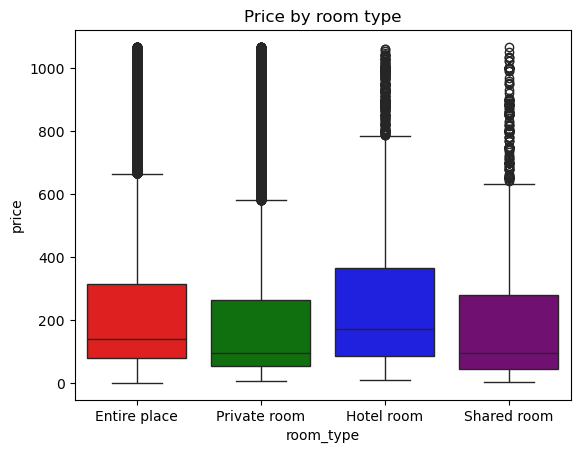

In [17]:
sns.boxplot(x="room_type", y="price", data=listing, palette=["red", "green", "blue", "purple"])
plt.title("Price by room type")
plt.show()

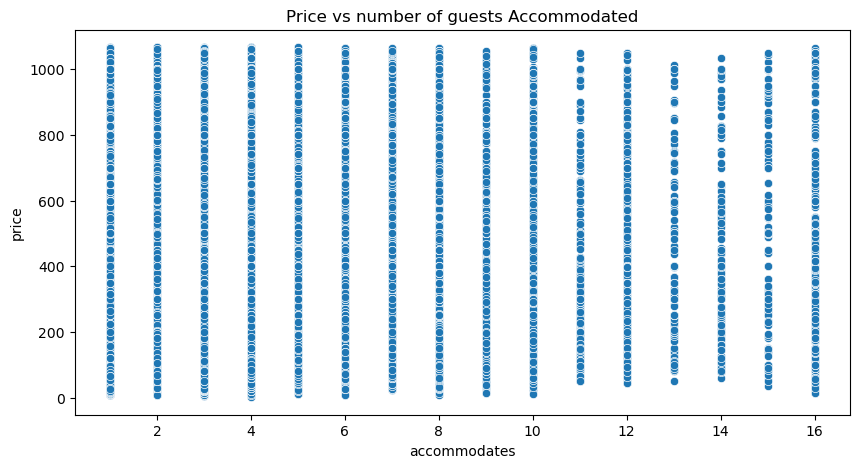

In [20]:
plt.figure(figsize=(10,5))
sns.scatterplot(x="accommodates", y="price", data=listing)
plt.title("Price vs number of guests Accommodated")
plt.show()

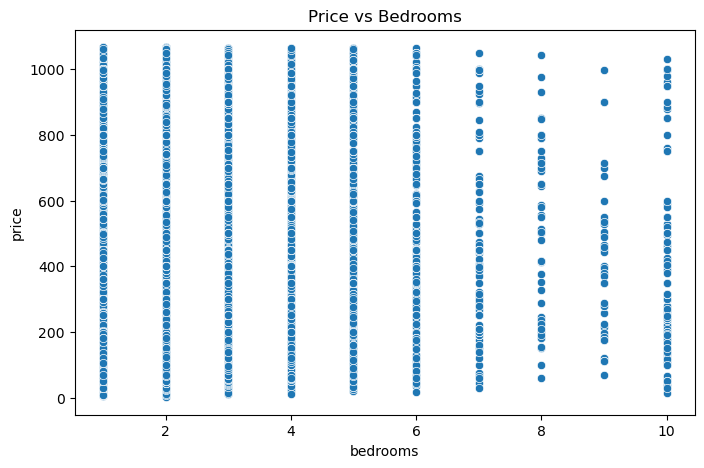

In [22]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="bedrooms", y="price", data=listing)
plt.title("Price vs Bedrooms")
plt.show()

In [25]:
cols = [
    "price",
    "accommodates",
    "bedrooms",
    "minimum_nights",
    "maximum_nights",
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_location",
    "review_scores_value"
]

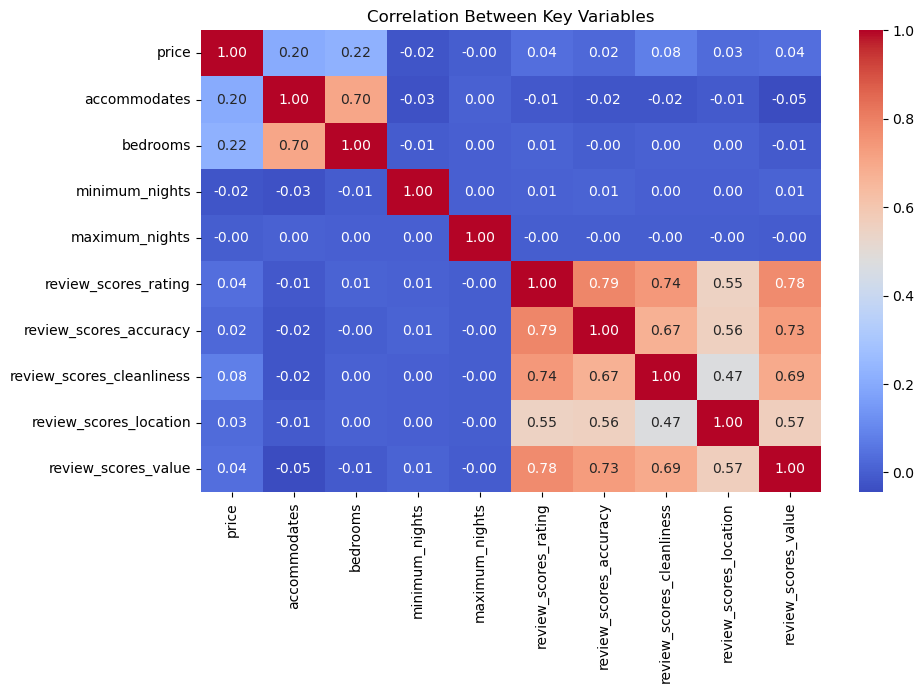

In [26]:
plt.figure(figsize=(10,6))
sns.heatmap(listing[cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Key Variables")
plt.show()

In [31]:
avg_price = listing.groupby("property_type")["price"].mean().sort_values(ascending=False).head(11)

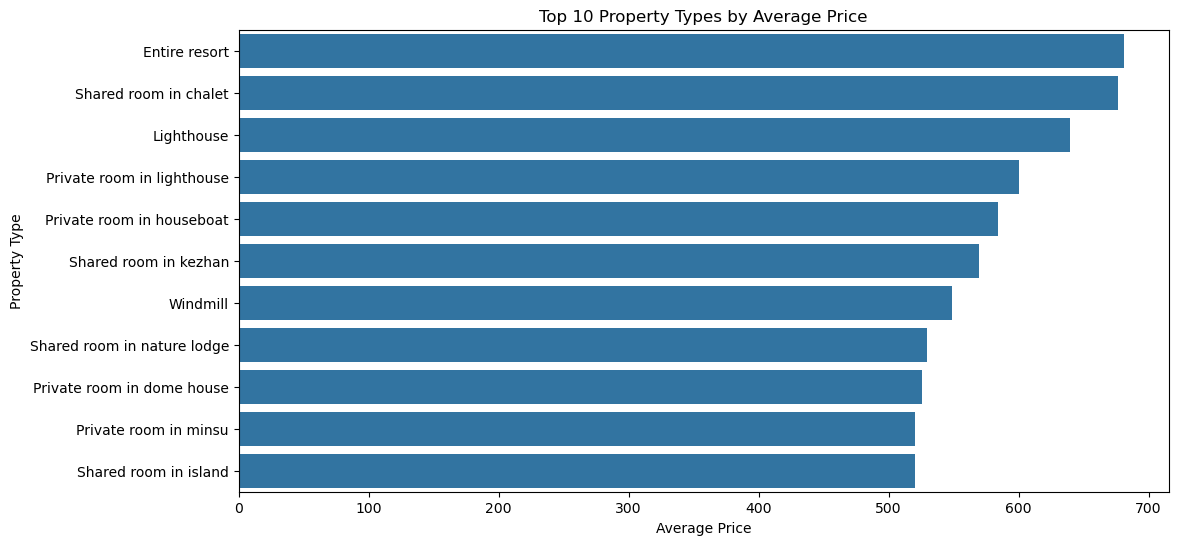

In [33]:
plt.figure(figsize=(12,6))
sns.barplot(x=avg_price.values, y=avg_price.index)
plt.title("Top 10 Property Types by Average Price")
plt.xlabel("Average Price")
plt.ylabel("Property Type")
plt.show()

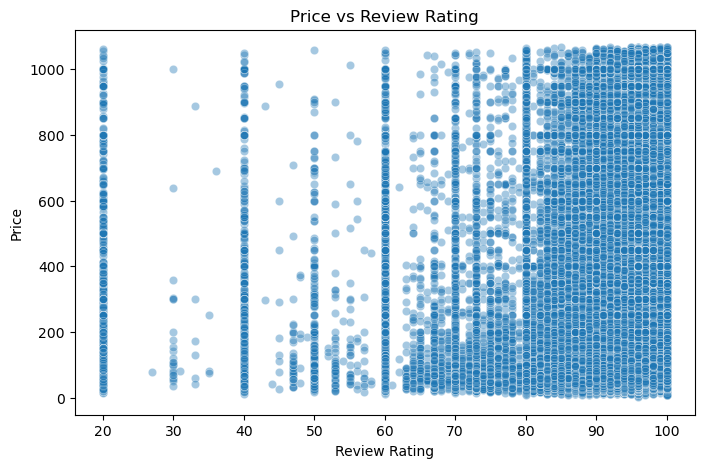

In [36]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="review_scores_rating", y="price", data=listing, alpha=0.4)

plt.title("Price vs Review Rating")
plt.xlabel("Review Rating")
plt.ylabel("Price")

plt.show()

In [38]:
listing["maximum_nights"] = listing["maximum_nights"].clip(upper=365)

In [40]:
listing = listing[listing["minimum_nights"]<=365]

In [44]:
listing["minimum_nights"].describe()

count    247882.000000
mean          7.909929
std          19.880244
min           1.000000
25%           1.000000
50%           2.000000
75%           5.000000
max         365.000000
Name: minimum_nights, dtype: float64

In [45]:
listing["maximum_nights"].describe()

count    247882.000000
mean        249.174474
std         156.350577
min           1.000000
25%          35.000000
50%         365.000000
75%         365.000000
max         365.000000
Name: maximum_nights, dtype: float64

In [46]:
listing.info()

<class 'pandas.DataFrame'>
Index: 247882 entries, 0 to 247968
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   247882 non-null  int64  
 1   name                         247732 non-null  str    
 2   host_id                      247882 non-null  int64  
 3   host_since                   247739 non-null  str    
 4   host_location                247882 non-null  str    
 5   host_response_time           247882 non-null  str    
 6   host_response_rate           247882 non-null  float64
 7   host_acceptance_rate         247882 non-null  float64
 8   host_is_superhost            247882 non-null  bool   
 9   host_total_listings_count    247882 non-null  float64
 10  host_has_profile_pic         247882 non-null  bool   
 11  host_identity_verified       247882 non-null  bool   
 12  neighbourhood                247882 non-null  str    
 13  city           

In [48]:
listing.to_csv(r"D:\Data Analyst\DA Project-2\Airbnb_Automated_Pipeline_Project\data\processed\clean_listings.csv", index=False)

## Exploratory Data Analysis (EDA) Summary

In this section, exploratory data analysis was performed to understand the distribution of Airbnb listing prices and identify key factors influencing price variations.

### 1. Price Distribution
The price distribution shows a **right-skewed pattern**, where most listings fall within the lower price range while a small number of listings have very high prices.

Key observations:
- Most listings are priced between **$50 and $300**.
- A small number of listings exceed **$600–$1000**, representing premium or luxury properties.

This indicates that the Airbnb market is dominated by moderately priced listings with a few high-end properties.

---

### 2. Price Outliers
Boxplot analysis revealed several **high-value outliers** in the price column.

These outliers are likely due to:
- Luxury properties
- Large accommodations
- Premium locations
- Unique stays such as villas or boutique hotels

Since these represent legitimate listings rather than data errors, they were **not removed during analysis**.

---

### 3. Price vs Room Type
The relationship between **room type and price** was analyzed.

Observations:
- **Entire place** listings generally have the highest prices.
- **Hotel rooms** also show relatively higher prices.
- **Private rooms** are moderately priced.
- **Shared rooms** tend to have the lowest prices.

This suggests that the level of privacy and space significantly influences listing prices.

---

### 4. Price vs Accommodation Capacity
Scatterplot analysis shows that listings accommodating **more guests tend to have higher prices**.

However, the relationship is not perfectly linear because price is also influenced by:
- property type
- location
- amenities
- host characteristics

---

### 5. Price vs Number of Bedrooms
Listings with **more bedrooms generally show higher prices**, although price variability still exists within each bedroom category.

This indicates that bedroom count contributes to pricing but is not the only determining factor.

---

### 6. Correlation Analysis
Correlation analysis was conducted on key numerical variables.

Key findings:
- **Accommodates and bedrooms show strong correlation**, which is expected because larger properties usually contain more bedrooms.
- Review score metrics such as **accuracy, cleanliness, location, and value are strongly correlated with overall ratings**.
- **Price shows relatively weak correlation with most variables**, indicating that multiple factors jointly influence listing prices.

---

## Overall Conclusion

The exploratory analysis indicates that Airbnb listing prices are primarily influenced by:

- Room type
- Accommodation capacity
- Number of bedrooms
- Property characteristics

The price distribution is heavily right-skewed with a small number of high-value listings acting as outliers. These outliers likely represent luxury properties rather than data anomalies.

Overall, pricing appears to be determined by a combination of property size, type, and guest capacity rather than any single variable alone.